# Training report cumulative reward

In [36]:
from pathlib import Path
import json

import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

REPORT_PATH = Path("eval") / "cmr_export"
SAVE_PATH = Path("eval") / "figures"
SAVE_PATH.mkdir(parents=True, exist_ok=True)

METHOD_NAMES = ["Random", "Random Ordered", "GA", "SpaceTimeRL"]
TASK_IDS = ["task1", "task2", "task3", "task4"]
TASK_HOLE_DENSITY = {
    "task1": "10%",
    "task2": "20%",
    "task3": "30%",
    "task4": "40%",
}
TASK_REPORTS = {
    task_id: [
        REPORT_PATH / task_id / "random.json",
        REPORT_PATH / task_id / "random_ordered.json",
        REPORT_PATH / task_id / "ga.json",
        REPORT_PATH / task_id / "spacetime_rl.json",
    ]
    for task_id in TASK_IDS
}
SUCCESS_RATES = {
    "task1": {
        "GA": {0: 0, 1000: 0, 2000: 3 / 5, 3000: 1},
        "Random": {0: 0, 1000: 0, 2000: 0, 3000: 4 / 5},
        "Random Ordered": {0: 0, 1000: 0, 2000: 0, 3000: 3 / 5},
        "SpaceTimeRL": {0: 0, 700: 1 / 2, 1900: 1, 3000: 1},
    },
    "task2": {
        "GA": {0: 0, 2000: 0, 4000: 1 / 5, 6000: 0, 8000: 1 / 5, 10000: 1},
        "Random": {0: 0, 2000: 0, 4000: 1 / 5, 6000: 0, 8000: 0, 10000: 4 / 5},
        "Random Ordered": {0: 0, 8000: 0, 10000: 4 / 5},
        "SpaceTimeRL": {0: 0, 1100: 1 / 2, 1851: 1, 10000: 1},
    },
    "task3": {
        "Random": {0: 0, 27000: 0, 30000: 4 / 5},
        "Random Ordered": {0: 0, 21000: 0, 24000: 1 / 5, 27000: 0, 30000: 3 / 5},
        "GA": {0: 0, 27000: 0, 30000: 1},
        "SpaceTimeRL": {0: 0, 1900: 1 / 2, 3900: 1, 30000: 1},
    },
    "task4": {
        "Random": {0: 0, 56000: 0, 60000: 4 / 5},
        "Random Ordered": {0: 0, 56000: 0, 60000: 2 / 5},
        "GA": {0: 0, 56000: 0, 60000: 3 / 5},
        "SpaceTimeRL": {0: 0, 2400: 1 / 2, 15900: 1, 60000: 1},
    },
}


def task_title(task_id: str) -> str:
    return f"{task_id.replace('task', 'Task ')} ({TASK_HOLE_DENSITY[task_id]} hole density)"


def reports_from_file(path: Path) -> list[dict]:
    with path.open("r", encoding="utf-8") as file:
        payload = json.load(file)
    reports = payload.get("reports")
    if isinstance(reports, list):
        return [item for item in reports if isinstance(item, dict)]
    return [payload]


def generate_df_rows(paths: list[Path], names: list[str]) -> list[dict]:
    rows = []
    for path, name in zip(paths, names):
        for run_index, report in enumerate(reports_from_file(path), start=1):
            label = report.get("target_label") or report.get("target_checkpoint_id") or f"Run {run_index}"
            for episode, cumulative_reward in report.get("cumulative_reward_points", []):
                rows.append({
                    "file": name,
                    "run": label,
                    "episode": int(episode),
                    "cumulative_reward": float(cumulative_reward),
                })
    return rows


In [37]:
sns.set_theme(style="whitegrid")


def save_plot(fig, save_path: Path) -> None:
    save_path.parent.mkdir(parents=True, exist_ok=True)
    fig.savefig(save_path, dpi=300, bbox_inches="tight")


def save_figure_versions(fig, output_base: Path) -> list[Path]:
    output_base.parent.mkdir(parents=True, exist_ok=True)
    output_paths = [output_base.with_suffix(".pdf"), output_base.with_suffix(".png")]
    fig.savefig(output_paths[0], bbox_inches="tight")
    fig.savefig(output_paths[1], dpi=300, bbox_inches="tight")
    return output_paths


def plot_cumulative_reward(
    paths: list[Path],
    names: list[str],
    save_path: Path | None = None,
    ax=None,
    title: str = "Average cumulative reward",
    show_legend: bool = True,
):
    rows = generate_df_rows(paths, names)
    df = pd.DataFrame(rows, columns=["file", "run", "episode", "cumulative_reward"])

    if ax is None:
        fig, ax = plt.subplots(figsize=(10, 5))
    else:
        fig = ax.figure

    sns.lineplot(
        data=df,
        x="episode",
        y="cumulative_reward",
        hue="file",
        estimator="mean",
        errorbar="sd",
        linewidth=2.2,
        legend=show_legend,
        ax=ax,
    )
    ax.set_title(title)
    ax.set_xlabel("Episode")
    ax.set_ylabel("Cumulative reward")

    legend = ax.get_legend()
    if legend is not None:
        legend.set_title(None)
        if not show_legend:
            legend.remove()

    if save_path:
        fig.tight_layout()
        save_plot(fig, save_path)

    return fig, ax, df


In [38]:
def success_rate_dataframe(success_rates: dict) -> pd.DataFrame:
    df = pd.DataFrame.from_dict(success_rates, orient="index").transpose()
    df = df.sort_index()
    ordered_columns = [name for name in METHOD_NAMES if name in df.columns]
    df = df[ordered_columns]
    df.index.name = "Episode"
    return df


def plot_success_rate(
    success_rates: dict,
    save_path: Path | None = None,
    ax=None,
    title: str = "Success rate",
    show_legend: bool = True,
):
    df = success_rate_dataframe(success_rates)

    if ax is None:
        fig, ax = plt.subplots(figsize=(6, 6))
    else:
        fig = ax.figure

    sns.lineplot(
        data=df,
        linewidth=2.2,
        dashes=False,
        legend=show_legend,
        ax=ax,
    )
    ax.set_title(title)
    ax.set_xlabel("Episode")
    ax.set_ylabel("Success rate")
    ax.set_ylim(-0.02, 1.02)

    legend = ax.get_legend()
    if legend is not None:
        legend.set_title(None)
        if not show_legend:
            legend.remove()

    if save_path:
        fig.tight_layout()
        save_plot(fig, save_path)

    return fig, ax, df


## Task 1

(<Figure size 1000x500 with 1 Axes>,
 <Axes: title={'center': 'Average cumulative reward'}, xlabel='Episode', ylabel='Cumulative reward'>,
               file                                                run  \
 0           Random  Checkpoint 003 | Frozen Lake 12x12 - RQ1 Task ...   
 1           Random  Checkpoint 003 | Frozen Lake 12x12 - RQ1 Task ...   
 2           Random  Checkpoint 003 | Frozen Lake 12x12 - RQ1 Task ...   
 3           Random  Checkpoint 003 | Frozen Lake 12x12 - RQ1 Task ...   
 4           Random  Checkpoint 003 | Frozen Lake 12x12 - RQ1 Task ...   
 ...            ...                                                ...   
 50995  SpaceTimeRL  Checkpoint 008 | Frozen Lake 12x12 - RQ1 Task ...   
 50996  SpaceTimeRL  Checkpoint 008 | Frozen Lake 12x12 - RQ1 Task ...   
 50997  SpaceTimeRL  Checkpoint 008 | Frozen Lake 12x12 - RQ1 Task ...   
 50998  SpaceTimeRL  Checkpoint 008 | Frozen Lake 12x12 - RQ1 Task ...   
 50999  SpaceTimeRL  Checkpoint 008 | Frozen La

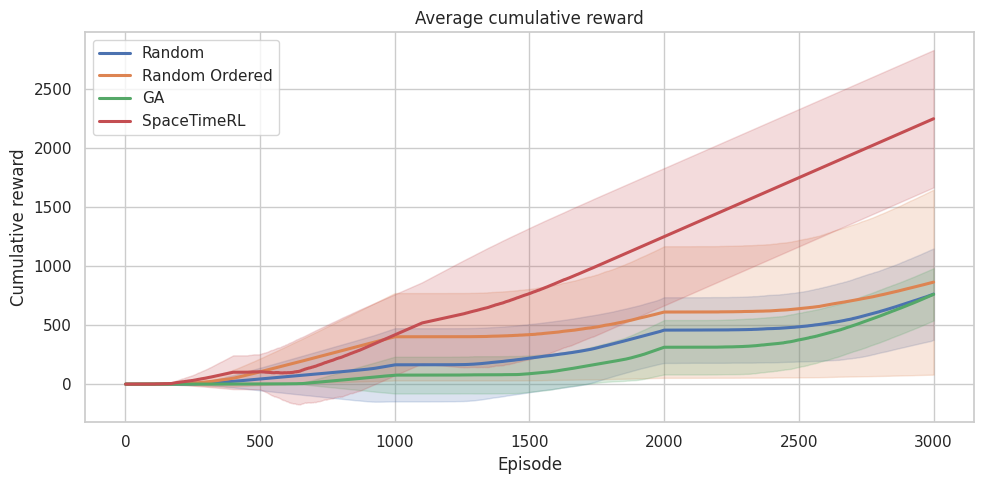

In [39]:
plot_cumulative_reward(
    [
        REPORT_PATH / "task1"/ "random.json",
        REPORT_PATH / "task1"/ "random_ordered.json",
        REPORT_PATH / "task1"/ "ga.json",
        REPORT_PATH / "task1"/ "spacetime_rl.json",
    ], ["Random", "Random Ordered", "GA", "SpaceTimeRL"],
    save_path=SAVE_PATH / "task1_cumulative_reward.png")

(<Figure size 600x600 with 1 Axes>,
 <Axes: title={'center': 'Success rate'}, xlabel='Episode', ylabel='Success rate'>,
          Random  Random Ordered   GA  SpaceTimeRL
 Episode                                          
 0           0.0             0.0  0.0          0.0
 700         NaN             NaN  NaN          0.5
 1000        0.0             0.0  0.0          NaN
 1900        NaN             NaN  NaN          1.0
 2000        0.0             0.0  0.6          NaN
 3000        0.8             0.6  1.0          1.0)

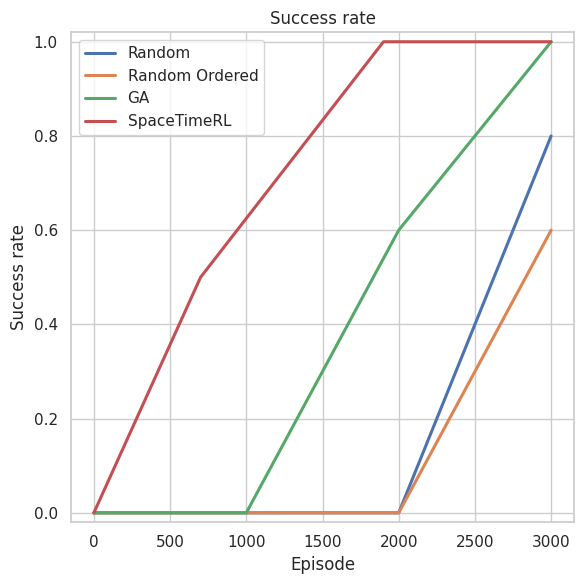

In [40]:
plot_success_rate({
    "GA":{
        0:0,
        1000:0,
        2000:3/5,
        3000:1
    },
    "Random":{
        0:0,
        1000:0,
        2000:0,
        3000:4/5
    },
    "Random Ordered":{
        0:0,
        1000:0,
        2000:0,
        3000:3/5
    },
    "SpaceTimeRL":{
        0:0,
        700:1/2,
        1900:1,
        3000:1,
    }
}, save_path=SAVE_PATH / "task1_success_rate.png")

## Task 2

(<Figure size 1000x500 with 1 Axes>,
 <Axes: title={'center': 'Average cumulative reward'}, xlabel='Episode', ylabel='Cumulative reward'>,
                file                                                run  \
 0            Random  Checkpoint 005 | Frozen Lake 12x12 - RQ1 Task ...   
 1            Random  Checkpoint 005 | Frozen Lake 12x12 - RQ1 Task ...   
 2            Random  Checkpoint 005 | Frozen Lake 12x12 - RQ1 Task ...   
 3            Random  Checkpoint 005 | Frozen Lake 12x12 - RQ1 Task ...   
 4            Random  Checkpoint 005 | Frozen Lake 12x12 - RQ1 Task ...   
 ...             ...                                                ...   
 169995  SpaceTimeRL  Checkpoint 011 | Frozen Lake 12x12 - RQ1 Task ...   
 169996  SpaceTimeRL  Checkpoint 011 | Frozen Lake 12x12 - RQ1 Task ...   
 169997  SpaceTimeRL  Checkpoint 011 | Frozen Lake 12x12 - RQ1 Task ...   
 169998  SpaceTimeRL  Checkpoint 011 | Frozen Lake 12x12 - RQ1 Task ...   
 169999  SpaceTimeRL  Checkpoint 011

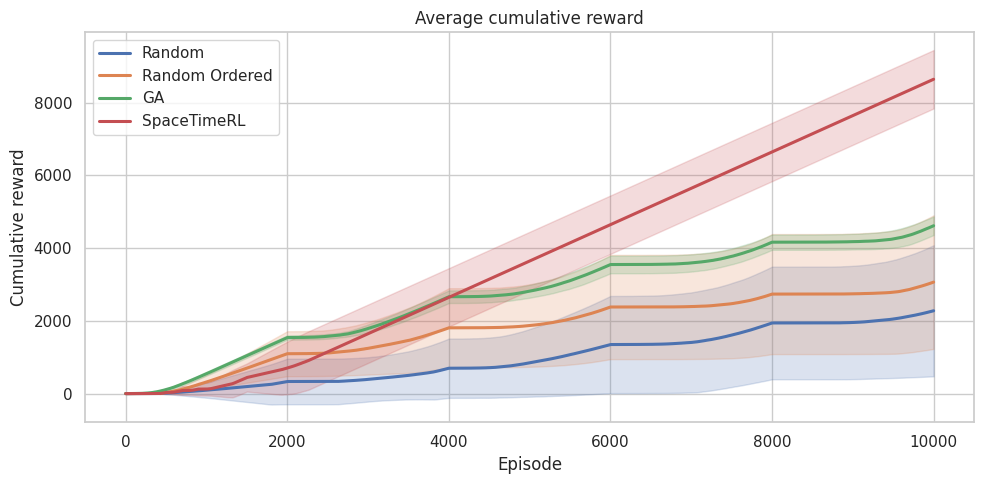

In [41]:
plot_cumulative_reward(
    [
        REPORT_PATH / "task2"/ "random.json",
        REPORT_PATH / "task2"/ "random_ordered.json",
        REPORT_PATH / "task2"/ "ga.json", # to fix: performance seems to be worse than random
        REPORT_PATH / "task2"/ "spacetime_rl.json",
    ], [
        "Random", 
        "Random Ordered", 
        "GA",
        "SpaceTimeRL"], 
    save_path=SAVE_PATH / "task2_cumulative_reward.png")

(<Figure size 600x600 with 1 Axes>,
 <Axes: title={'center': 'Success rate'}, xlabel='Episode', ylabel='Success rate'>,
          Random  Random Ordered   GA  SpaceTimeRL
 Episode                                          
 0           0.0             0.0  0.0          0.0
 1100        NaN             NaN  NaN          0.5
 1851        NaN             NaN  NaN          1.0
 2000        0.0             NaN  0.0          NaN
 4000        0.2             NaN  0.2          NaN
 6000        0.0             NaN  0.0          NaN
 8000        0.0             0.0  0.2          NaN
 10000       0.8             0.8  1.0          1.0)

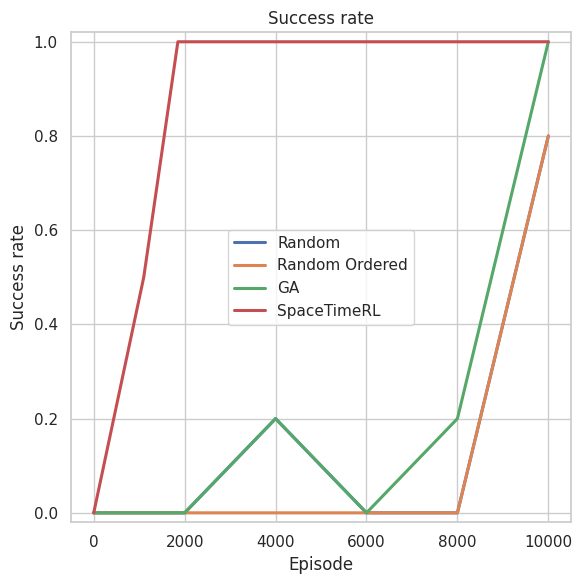

In [42]:
plot_success_rate({
    "GA":{
        0:0,
        2000:0,
        4000:1/5,
        6000:0,
        8000:1/5,
        10000:1
    },
    "Random":{
        0:0,
        2000:0,
        4000:1/5,
        6000:0,
        8000:0,
        10000:4/5
    },
    "Random Ordered":{
        0:0,
        8000:0,
        10000:4/5
    },
    "SpaceTimeRL":{
        0:0,
        1100:1/2,
        1851:1,
        10000:1,
    }
}, save_path=SAVE_PATH / "task2_success_rate.png")

## Task 3

(<Figure size 1000x500 with 1 Axes>,
 <Axes: title={'center': 'Average cumulative reward'}, xlabel='Episode', ylabel='Cumulative reward'>,
                file                                                run  \
 0            Random  Checkpoint 010 | Frozen Lake 12x12 - RQ1 Task ...   
 1            Random  Checkpoint 010 | Frozen Lake 12x12 - RQ1 Task ...   
 2            Random  Checkpoint 010 | Frozen Lake 12x12 - RQ1 Task ...   
 3            Random  Checkpoint 010 | Frozen Lake 12x12 - RQ1 Task ...   
 4            Random  Checkpoint 010 | Frozen Lake 12x12 - RQ1 Task ...   
 ...             ...                                                ...   
 509995  SpaceTimeRL  Checkpoint 014 | Frozen Lake 12x12 - RQ1 Task ...   
 509996  SpaceTimeRL  Checkpoint 014 | Frozen Lake 12x12 - RQ1 Task ...   
 509997  SpaceTimeRL  Checkpoint 014 | Frozen Lake 12x12 - RQ1 Task ...   
 509998  SpaceTimeRL  Checkpoint 014 | Frozen Lake 12x12 - RQ1 Task ...   
 509999  SpaceTimeRL  Checkpoint 014

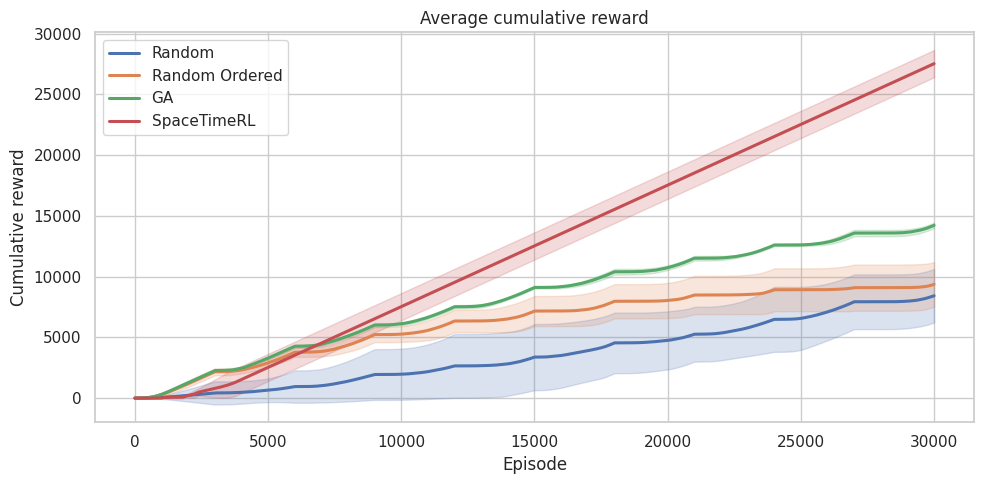

In [43]:
plot_cumulative_reward(
    [
        REPORT_PATH / "task3"/ "random.json",
        REPORT_PATH / "task3"/ "random_ordered.json",
        REPORT_PATH / "task3"/ "ga.json",
        REPORT_PATH / "task3"/ "spacetime_rl.json",
    ], ["Random", "Random Ordered", "GA", 
        "SpaceTimeRL"
    ], save_path=SAVE_PATH / "task3_cumulative_reward.png")

(<Figure size 600x600 with 1 Axes>,
 <Axes: title={'center': 'Success rate'}, xlabel='Episode', ylabel='Success rate'>,
          Random  Random Ordered   GA  SpaceTimeRL
 Episode                                          
 0           0.0             0.0  0.0          0.0
 1900        NaN             NaN  NaN          0.5
 3900        NaN             NaN  NaN          1.0
 21000       NaN             0.0  NaN          NaN
 24000       NaN             0.2  NaN          NaN
 27000       0.0             0.0  0.0          NaN
 30000       0.8             0.6  1.0          1.0)

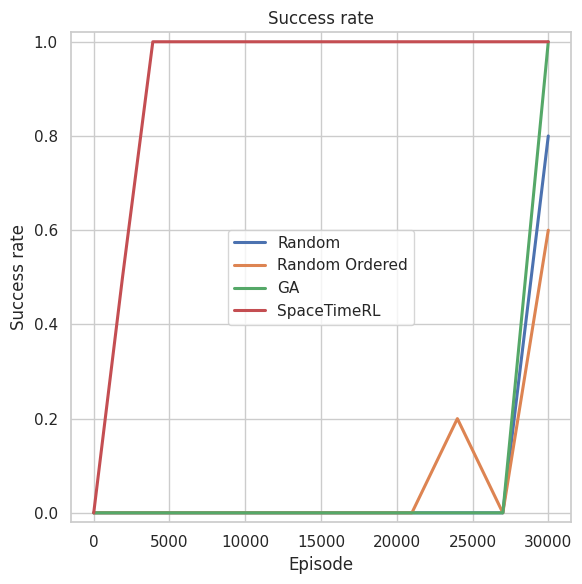

In [44]:
plot_success_rate({
    "Random":{
        0:0,
        27000:0,
        30000:4/5
    },
    "Random Ordered":{
        0:0,
        21000:0,
        24000:1/5,
        27000:0,
        30000:3/5
    },
    "GA":{
        0:0,
        27000:0,
        30000:1
    },
    "SpaceTimeRL":{
        0:0,
        1900:1/2,
        3900:1,
        30000:1
    }
}, save_path=SAVE_PATH / "task3_success_rate.png")

## Task 4

(<Figure size 1000x500 with 1 Axes>,
 <Axes: title={'center': 'Average cumulative reward'}, xlabel='Episode', ylabel='Cumulative reward'>,
                 file                                                run  \
 0             Random  Checkpoint 075 | Frozen Lake 12x12 - RQ1 Task ...   
 1             Random  Checkpoint 075 | Frozen Lake 12x12 - RQ1 Task ...   
 2             Random  Checkpoint 075 | Frozen Lake 12x12 - RQ1 Task ...   
 3             Random  Checkpoint 075 | Frozen Lake 12x12 - RQ1 Task ...   
 4             Random  Checkpoint 075 | Frozen Lake 12x12 - RQ1 Task ...   
 ...              ...                                                ...   
 1019995  SpaceTimeRL  Checkpoint 016 | Frozen Lake 12x12 - RQ1 Task ...   
 1019996  SpaceTimeRL  Checkpoint 016 | Frozen Lake 12x12 - RQ1 Task ...   
 1019997  SpaceTimeRL  Checkpoint 016 | Frozen Lake 12x12 - RQ1 Task ...   
 1019998  SpaceTimeRL  Checkpoint 016 | Frozen Lake 12x12 - RQ1 Task ...   
 1019999  SpaceTimeRL  Ch

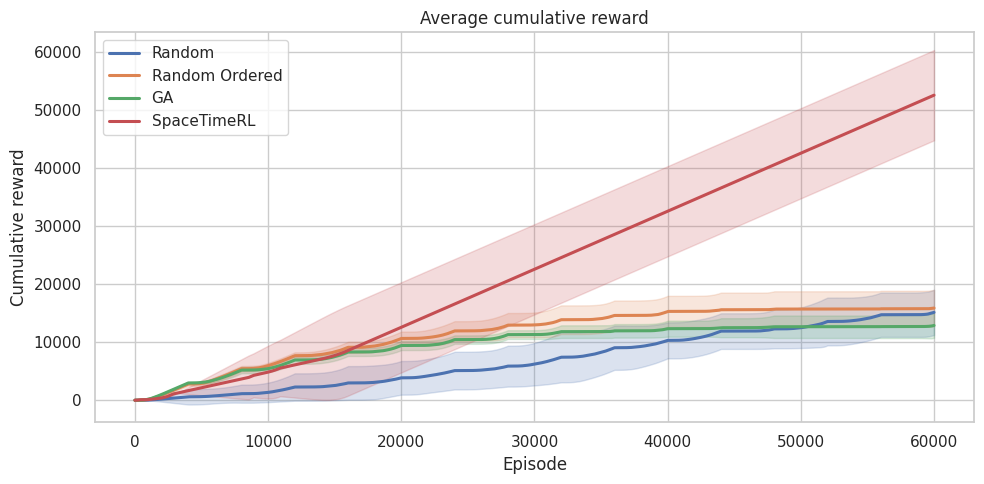

In [45]:
plot_cumulative_reward(
    [
        REPORT_PATH / "task4"/ "random.json",
        REPORT_PATH / "task4"/ "random_ordered.json",
        REPORT_PATH / "task4"/ "ga.json",
        REPORT_PATH / "task4"/ "spacetime_rl.json",
    ], ["Random", "Random Ordered", "GA", "SpaceTimeRL"],
    save_path=SAVE_PATH / "task4_cumulative_reward.png")

(<Figure size 600x600 with 1 Axes>,
 <Axes: title={'center': 'Success rate'}, xlabel='Episode', ylabel='Success rate'>,
          Random  Random Ordered   GA  SpaceTimeRL
 Episode                                          
 0           0.0             0.0  0.0          0.0
 2400        NaN             NaN  NaN          0.5
 15900       NaN             NaN  NaN          1.0
 56000       0.0             0.0  0.0          NaN
 60000       0.8             0.4  0.6          1.0)

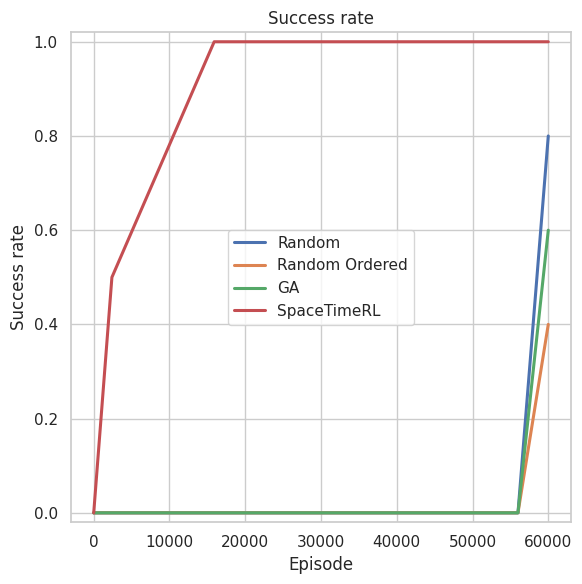

In [46]:
plot_success_rate({
    "Random":{
        0:0,
        56000:0,
        60000:4/5
    },
    "Random Ordered":{
        0:0,
        56000:0,
        60000:2/5
    },
    "GA":{
        0:0,
        56000:0,
        60000:3/5
    },
    "SpaceTimeRL":{
        0:0,
        2400:1/2,
        15900:1,
        60000:1
    }
}, save_path=SAVE_PATH / "task4_success_rate.png")

## Combined report figures

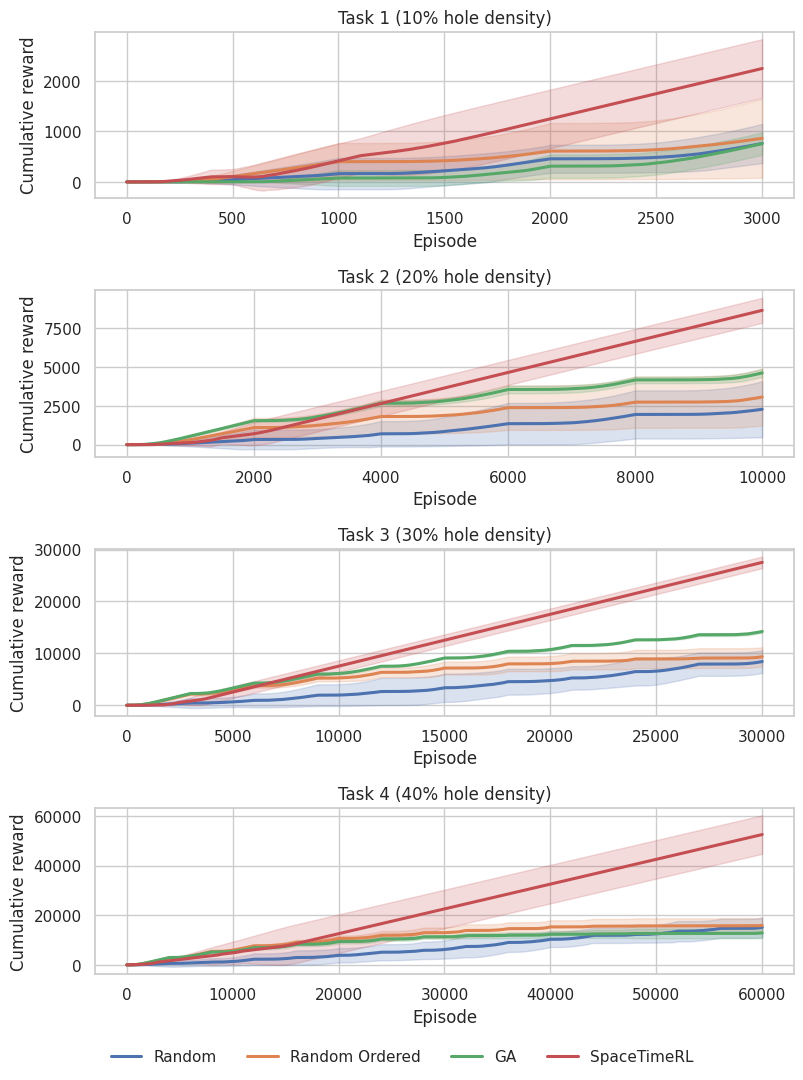

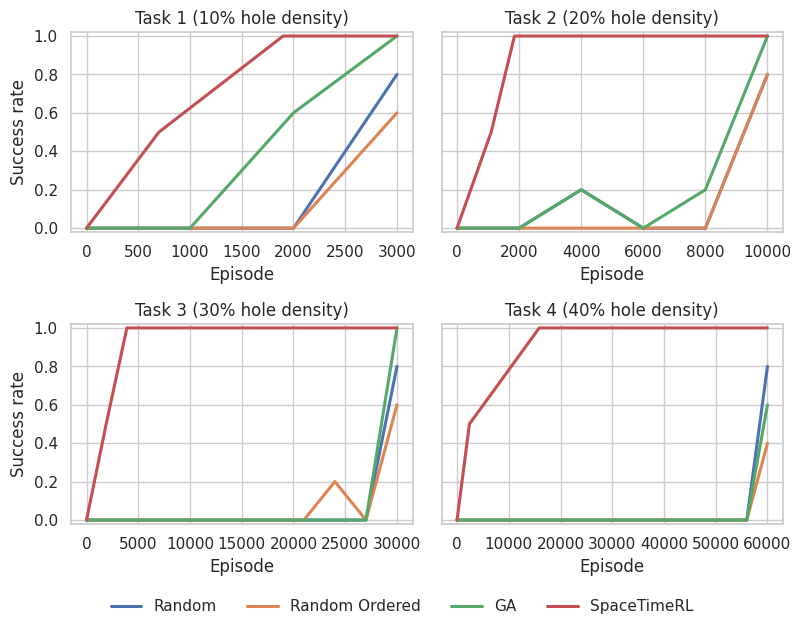

In [47]:
def add_shared_legend(fig, source_ax, *, bottom: float, ncol: int = 4) -> None:
    handles, labels = source_ax.get_legend_handles_labels()
    for ax in fig.axes:
        legend = ax.get_legend()
        if legend is not None:
            legend.remove()
    fig.legend(
        handles,
        labels,
        loc="lower center",
        bbox_to_anchor=(0.5, bottom),
        ncol=ncol,
        frameon=False,
    )


def plot_all_cumulative_rewards(
    task_ids: list[str] = TASK_IDS,
    save_base: Path | None = None,
):
    fig, axes = plt.subplots(len(task_ids), 1, figsize=(8.2, 11.2), sharex=False)
    first_ax = axes[0]

    for ax, task_id in zip(axes, task_ids):
        plot_cumulative_reward(
            TASK_REPORTS[task_id],
            METHOD_NAMES,
            ax=ax,
            title=task_title(task_id),
            show_legend=(ax is first_ax),
        )

    #fig.suptitle("Average cumulative reward by hole density", fontsize=14)
    add_shared_legend(fig, first_ax, bottom=0.005, ncol=len(METHOD_NAMES))
    fig.tight_layout(rect=(0, 0.035, 1, 0.975))

    if save_base:
        save_figure_versions(fig, save_base)

    return fig, axes


def plot_all_success_rates(
    task_ids: list[str] = TASK_IDS,
    save_base: Path | None = None,
):
    fig, axes = plt.subplots(2, 2, figsize=(8.2, 6.8), sharex=False, sharey=True)
    flat_axes = axes.ravel()
    first_ax = flat_axes[0]

    for ax, task_id in zip(flat_axes, task_ids):
        plot_success_rate(
            SUCCESS_RATES[task_id],
            ax=ax,
            title=task_title(task_id),
            show_legend=(ax is first_ax),
        )

    #fig.suptitle("Success rate by hole density", fontsize=14)
    add_shared_legend(fig, first_ax, bottom=0.005, ncol=len(METHOD_NAMES))
    fig.tight_layout(rect=(0, 0.055, 1, 0.94))

    if save_base:
        save_figure_versions(fig, save_base)

    return fig, axes


combined_cumulative_reward_fig, _ = plot_all_cumulative_rewards(
    save_base=SAVE_PATH / "all_cumulative_reward_by_hole_density"
)
combined_success_rate_fig, _ = plot_all_success_rates(
    save_base=SAVE_PATH / "all_success_rate_by_hole_density"
)
